# Notebook 03: Exploratory Data Analysis

## Objective

The purpose of this notebook is to explore the wide receiver dataset created during the data collection and integration phase. Exploratory Data Analysis (EDA) is used to understand the structure, quality, and characteristics of the data before feature engineering and predictive modeling.

The analyses performed in this notebook will help identify trends, distributions, potential outliers, relationships among variables, and opportunities for feature selection in later stages of the project.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from pathlib import Path

data_path = Path("../data/processed/wr_master.csv")

wr_master = pl.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Shape: {wr_master.shape}")

Dataset loaded successfully!
Shape: (3148, 181)


## Dataset Overview

The dataset contains one observation for each wide receiver and season. Before selecting variables for detailed analysis, the dataset structure, data types, and missing values are examined to verify that the imported data are consistent with expectations.

### Table 1. Dataset Data-Type Summary

Numeric variables represent player performance, usage, and physical characteristics, while string variables primarily contain identifiers and descriptive metadata.

In [3]:
# Count columns by data type
dtype_counts = (
    pl.DataFrame(
        {
            "Data Type": [str(dtype) for dtype in wr_master.dtypes]
        }
    )
    .group_by("Data Type")
    .len()
    .rename({"len": "Count"})
    .sort("Count", descending=True)
)

dtype_counts

Data Type,Count
str,u32
"""Int64""",127
"""String""",41
"""Float64""",13


### Interpretation

Most variables are numeric, including 127 integer variables and 13 floating-point variables. The 41 string variables largely represent player identifiers, team information, positions, and external database references. 

### Table 2. Variables With Substantial Missingness

Variables containing at least 10% missing values are examined to distinguish genuine data quality concerns from fields that are inapplicable to wide receivers. Missing values are documented during EDA but are not imputed or removed at this stage.

In [4]:
# Calculate missing values for each variable
missing_summary = (
    wr_master.null_count()
    .transpose(
        include_header=True,
        header_name="Variable",
        column_names=["Missing Values"]
    )
    .filter(pl.col("Missing Values") > 0)
    .with_columns(
        (
            pl.col("Missing Values") / wr_master.height * 100
        )
        .round(2)
        .alias("Percent Missing")
    )
    .sort("Percent Missing", descending=True)
)

# Retain variables with at least 10% missing values
high_missing_summary = (
    missing_summary
    .filter(pl.col("Percent Missing") >= 10)
)

high_missing_summary

Variable,Missing Values,Percent Missing
str,u32,f64
"""fg_long""",3148,100.0
"""fg_pct""",3148,100.0
"""fg_made_list""",3148,100.0
"""fg_missed_list""",3148,100.0
"""fg_blocked_list""",3148,100.0
…,…,…
"""draft_pick""",1006,31.96
"""draft_team""",1006,31.96
"""college_conference""",767,24.36


### Interpretation

Several kicking related variables are entirely missing because they are not applicable to wide receivers. These columns remain from the broader player statistics source and will be excluded during feature engineering.

Draft round and draft pick are missing for approximately 32% of observations, largely because undrafted players do not have draft values. College conference and selected player metadata also contain moderate missingness. These patterns require feature-specific treatment rather than blanket row deletion.

## Candidate Variables for Exploratory Analysis
The full dataset contains many position specific and administrative variables that are not directly relevant to predicting wide receiver performance. A focused subset was selected to represent player characteristics, offensive opportunity, receiving production, efficiency, ball security, and fantasy production.

Player identifiers and team information are retained for context but will not automatically be used as model predictors.

In [5]:
eda_columns = [
    "player_id",
    "player_name",
    "season",
    "recent_team",
    "height",
    "weight",
    "years_of_experience",
    "draft_round",
    "draft_pick",
    "games",
    "targets",
    "target_share",
    "air_yards_share",
    "receptions",
    "receiving_yards",
    "receiving_tds",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_epa",
    "racr",
    "wopr",
    "receiving_fumbles",
    "receiving_fumbles_lost",
    "fantasy_points",
    "fantasy_points_ppr",
]

eda_df = wr_master.select(eda_columns)

print(f"EDA dataset shape: {eda_df.shape}")


EDA dataset shape: (3148, 26)


## Descriptive Statistics

### Table 3. Descriptive Statistics for Candidate Numerical Variables

The table reports the number of valid observations, missing values, mean, standard deviation, minimum, quartiles, median, and maximum for each selected numerical variable. These statistics summarize the scale, variability, and distribution of the candidate predictors before preprocessing.

In [6]:
# Select only numeric variables
numeric_df = eda_df.select(pl.selectors.numeric())

# Build one row per numeric variable
summary_rows = []

for col in numeric_df.columns:
    series = numeric_df[col]

    summary_rows.append({
        "Variable": col,
        "Count": series.len() - series.null_count(),
        "Missing": series.null_count(),
        "Mean": float(series.mean()) if series.mean() is not None else None,
        "Std Dev": float(series.std()) if series.std() is not None else None,
        "Min": float(series.min()) if series.min() is not None else None,
        "Q1": float(series.quantile(0.25)) if series.quantile(0.25) is not None else None,
        "Median": float(series.median()) if series.median() is not None else None,
        "Q3": float(series.quantile(0.75)) if series.quantile(0.75) is not None else None,
        "Max": float(series.max()) if series.max() is not None else None,
    })

summary_table = (
    pl.DataFrame(summary_rows)
    .with_columns(
        pl.col("Count").cast(pl.Int64),
        pl.col("Missing").cast(pl.Int64),
        pl.col("Mean", "Std Dev", "Min", "Q1", "Median", "Q3", "Max")
        .cast(pl.Float64)
        .round(2)
    )
)

summary_table

Variable,Count,Missing,Mean,Std Dev,Min,Q1,Median,Q3,Max
str,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""season""",3148,0,2018.7,4.01,2012.0,2015.0,2019.0,2022.0,2025.0
"""height""",3148,0,72.52,2.41,65.0,71.0,73.0,74.0,78.0
"""weight""",3148,0,200.26,15.36,153.0,190.0,200.0,211.0,245.0
"""years_of_experience""",3148,0,6.55,3.34,0.0,4.0,6.0,9.0,17.0
"""draft_round""",2142,1006,3.33,1.9,1.0,2.0,3.0,5.0,7.0
…,…,…,…,…,…,…,…,…,…
"""wopr""",3148,0,0.2,0.2,0.0,0.03,0.14,0.33,0.95
"""receiving_fumbles""",3148,0,0.29,0.61,0.0,0.0,0.0,0.0,4.0
"""receiving_fumbles_lost""",3148,0,0.16,0.42,0.0,0.0,0.0,0.0,3.0


### Interpretation

The descriptive statistics reveal substantial variation in wide receiver usage and production. Receiving yards have a median of 216 but a mean of approximately 361, indicating a right-skewed distribution influenced by a smaller number of high-production seasons.

Targets, receptions, receiving air yards, yards after catch, and fantasy points show similar differences between their medians and means. Draft round and draft pick contain 1,006 missing observations, while receiving EPA and RACR contain smaller amounts of missing data.

Negative minimum values for receiving yards, air yards, yards after catch, and EPA are possible because individual plays may produce losses. These values are not automatically treated as errors.

## Figure 1. Distribution of Receiving Yards

### Purpose

This figure examines the distribution of current season receiving yards across wide receiver player seasons. Understanding the response variable's shape helps identify skewness, concentration, and extreme observations that may affect later preprocessing and model selection.

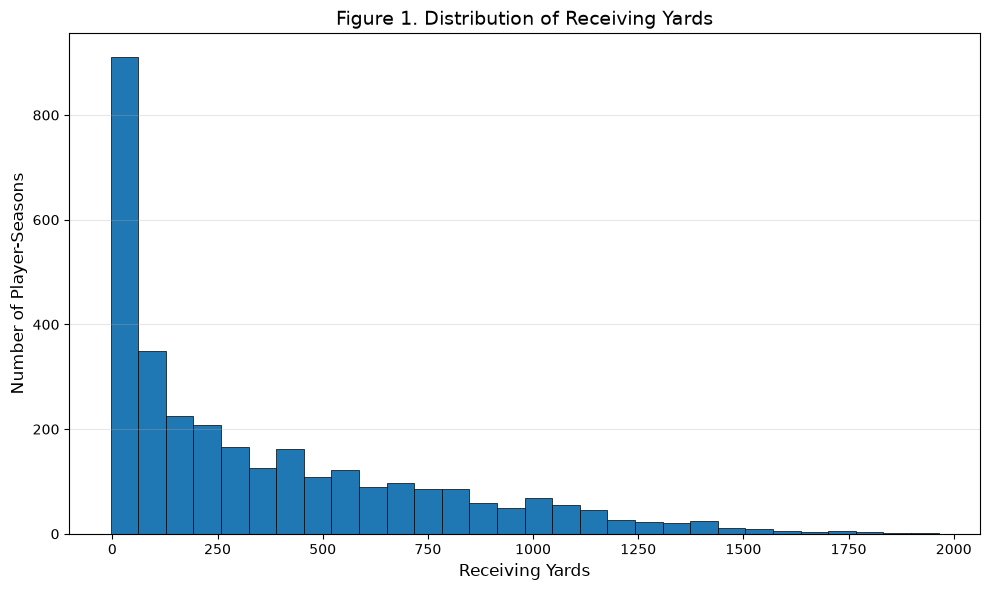

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    eda_df["receiving_yards"],
    bins=30,
    edgecolor="black",
    linewidth=0.5
)

plt.title("Figure 1. Distribution of Receiving Yards", fontsize=14)
plt.xlabel("Receiving Yards", fontsize=12)
plt.ylabel("Number of Player-Seasons", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Receiving yards are strongly right skewed. Most wide receiver player seasons fall toward the lower end of the distribution, while a much smaller number exceed 1,000 yards. The long right tail represents high volume and elite receiving seasons rather than an obvious data quality problem.

## Figure 2. Targets and Receiving Yards

### Purpose

This figure examines the relationship between receiving opportunities and receiving production. Targets represent how often a player is selected as the intended receiver, while receiving yards measure the resulting production.

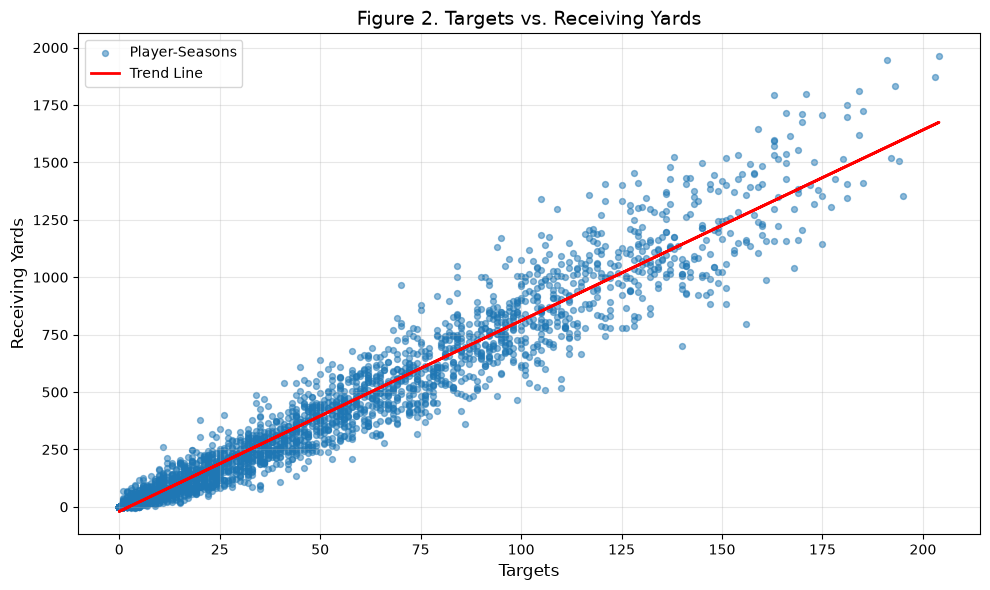

In [8]:
# Calculate regression line
m, b = np.polyfit(
    eda_df["targets"],
    eda_df["receiving_yards"],
    1
)

plt.figure(figsize=(10, 6))

plt.scatter(
    eda_df["targets"],
    eda_df["receiving_yards"],
    alpha=0.5,
    s=18,
    label="Player-Seasons"
)

plt.plot(
    eda_df["targets"],
    m * eda_df["targets"] + b,
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Figure 2. Targets vs. Receiving Yards", fontsize=14)
plt.xlabel("Targets", fontsize=12)
plt.ylabel("Receiving Yards", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

Targets and receiving yards display a strong, approximately linear positive relationship. Players receiving more targets generally accumulate more receiving yards. The vertical spread grows at higher target totals, indicating that receivers with similar opportunity levels can still differ meaningfully in efficiency and production.

## Figure 3. Correlation Matrix of Candidate Predictor Variables

### Purpose

Correlation analysis measures the strength and direction of linear relationships among the selected numerical variables. The analysis helps identify variables strongly associated with receiving yards and potential multicollinearity among predictors.

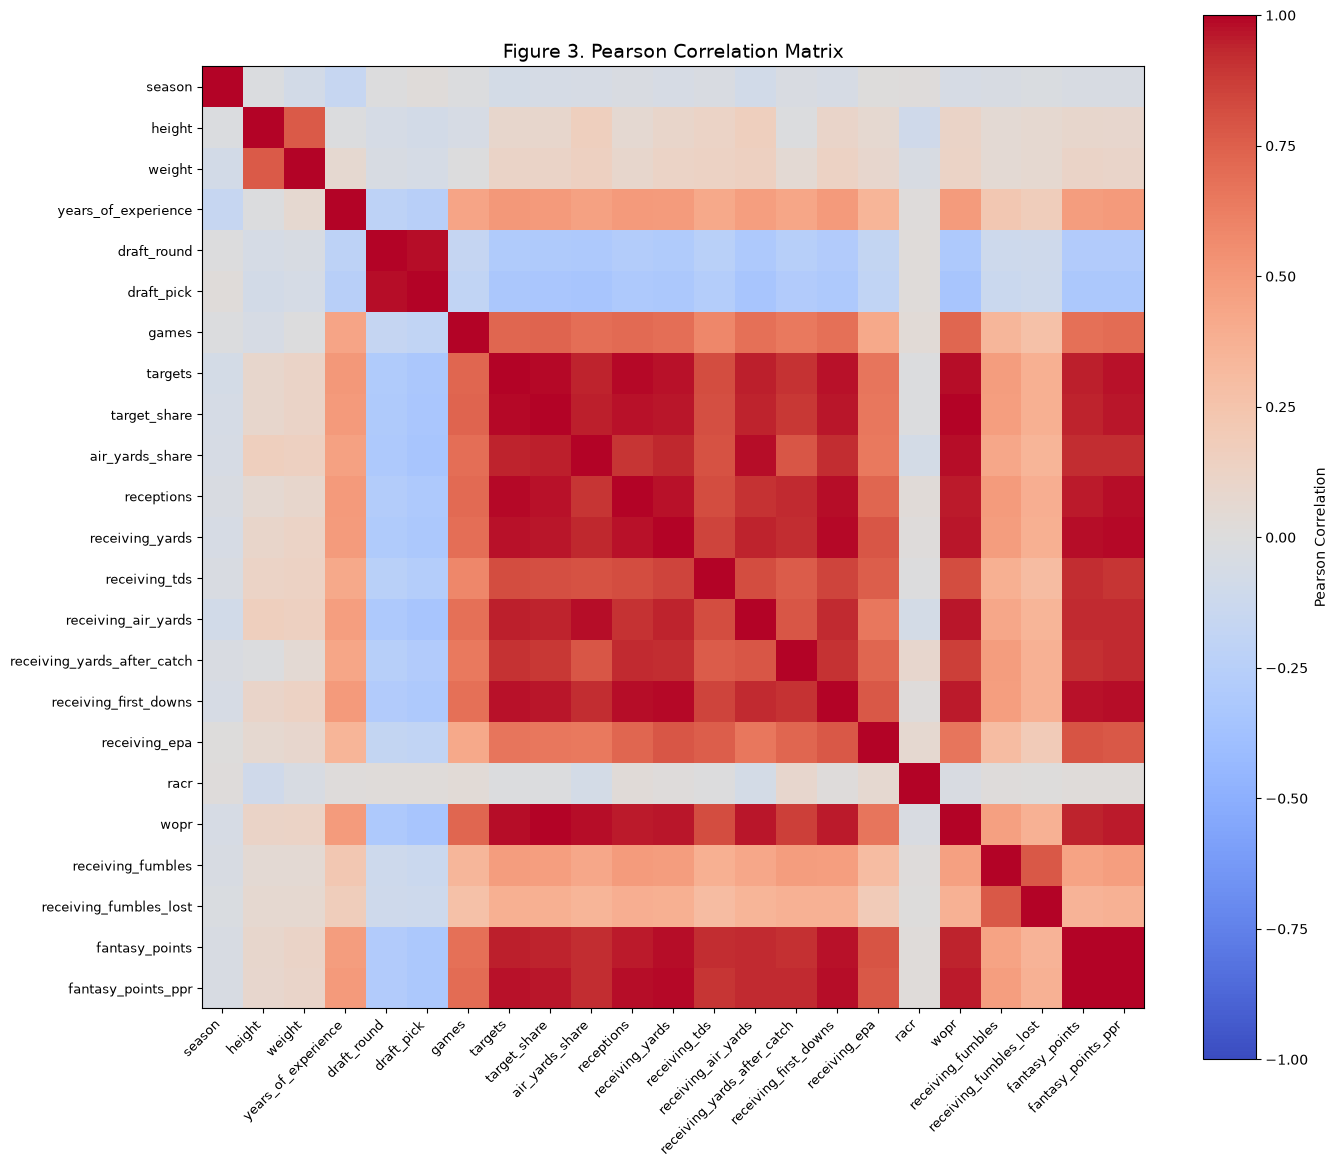

In [23]:
corr_df = (
    numeric_df
    .fill_nan(None)
    .fill_null(strategy="mean")
)

corr_matrix = corr_df.corr()
corr = corr_matrix.to_numpy()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(
    corr_matrix.columns,
    rotation=45,
    ha="right",
    fontsize=9
)

ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(
    corr_matrix.columns,
    fontsize=9
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson Correlation")

ax.set_title("Figure 3. Pearson Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()

### Interpretation

The heatmap reveals a large cluster of strongly correlated receiving production variables. Targets, receptions, receiving first downs, receiving air yards, target share, WOPR, and fantasy scoring measures move closely with receiving yards and with one another.

## Table 4. Variables Most Strongly Correlated With Receiving Yards

The table provides exact Pearson correlation coefficients for the ten variables most strongly associated with current-season receiving yards. It complements Figure 3 by reporting precise values rather than requiring visual estimation.

In [10]:
receiving_corr = (
    pl.DataFrame({
        "Variable": corr_matrix.columns,
        "Correlation": corr_matrix["receiving_yards"]
    })
    .filter(pl.col("Variable") != "receiving_yards")
    .sort("Correlation", descending=True)
    .with_columns(
        pl.col("Correlation").round(3)
    )
)

receiving_corr.head(10)

Variable,Correlation
str,f64
"""fantasy_points_ppr""",0.988
"""receiving_first_downs""",0.985
"""fantasy_points""",0.981
"""receptions""",0.972
"""targets""",0.972
"""wopr""",0.964
"""target_share""",0.963
"""receiving_air_yards""",0.944
"""air_yards_share""",0.936


### Interpretation

Fantasy points PPR, receiving first downs, fantasy points, receptions, and targets have the strongest correlations with receiving yards. WOPR, target share, receiving air yards, air yards share, and yards after catch are also strongly associated with production.

These results confirm that opportunity and receiving volume dominate current season production. They also reinforce the need to control redundancy during feature selection.

## Figure 4. Distribution and Outliers of Key Performance Variables

### Purpose

Boxplots are used to examine the medians, interquartile ranges, overall spread, and potential outliers in receiving yards, targets, and fantasy points. In professional sports data, extreme observations may represent legitimate elite performances rather than errors.

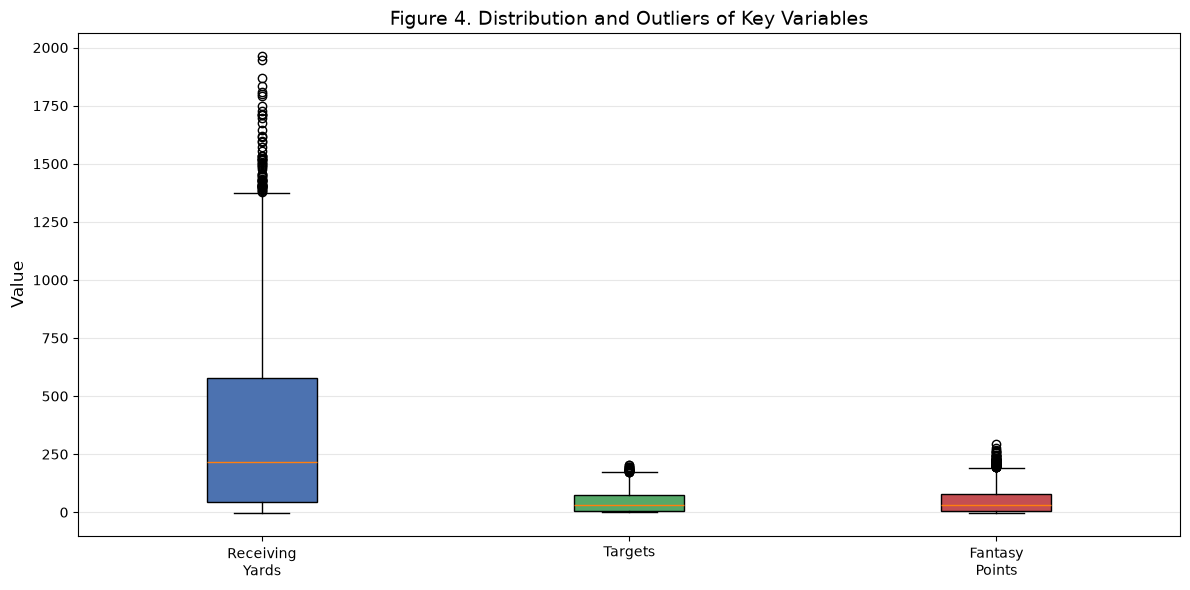

In [11]:
boxplot_vars = [
    "receiving_yards",
    "targets",
    "fantasy_points"
]

plt.figure(figsize=(12, 6))

box = plt.boxplot(
    [eda_df[col].to_list() for col in boxplot_vars],
    tick_labels=[
        "Receiving\nYards",
        "Targets",
        "Fantasy\nPoints"
    ],
    patch_artist=True
)

colors = ["#4C72B0", "#55A868", "#C44E52"]

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)

plt.title(
    "Figure 4. Distribution and Outliers of Key Variables",
    fontsize=14
)
plt.ylabel("Value", fontsize=12)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Receiving yards show the widest distribution and the largest number of high end outliers. Targets and fantasy points also contain observations beyond their upper whiskers, although their numerical scales are smaller.

## Figure 5. Previous-Season vs. Next Season Receiving Yards

### Purpose

This scatterplot examines the relationship between a wide receiver's receiving yards in one season and their receiving yards during the following season.

In [12]:
model_df = pl.read_csv("../data/processed/wr_model.csv")

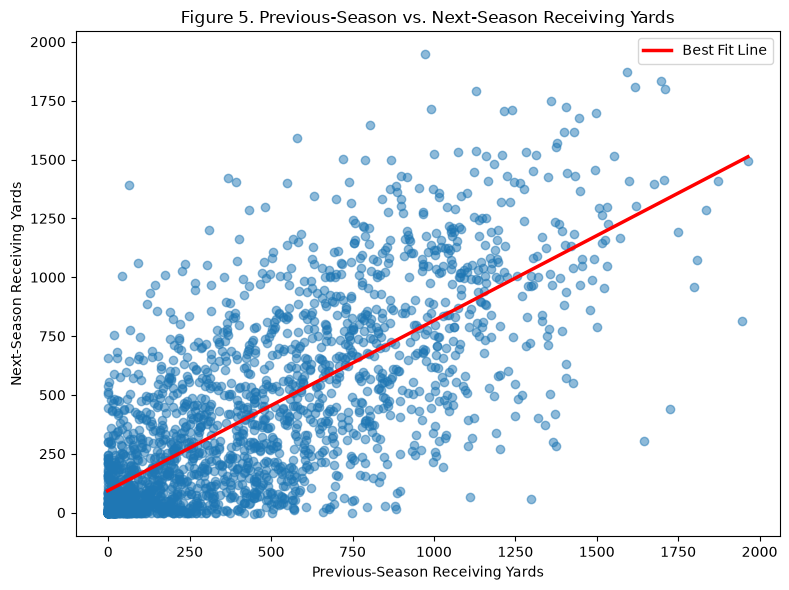

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Create plotting dataset

plot_df = (
    model_df
    .select([
        "receiving_yards",
        "next_season_receiving_yards"
    ])
    .drop_nulls()
)

x = plot_df["receiving_yards"].to_numpy()
y = plot_df["next_season_receiving_yards"].to_numpy()

# Fit regression line
slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    alpha=0.5
)

plt.plot(
    np.sort(x),
    slope * np.sort(x) + intercept,
    color="red",
    linewidth=2.5,
    label="Best Fit Line"
)

plt.legend()

plt.title("Figure 5. Previous-Season vs. Next-Season Receiving Yards")
plt.xlabel("Previous-Season Receiving Yards")
plt.ylabel("Next-Season Receiving Yards")

plt.tight_layout()
plt.show()

### Interpretation

Wide receivers with higher receiving yardage in one season generally tend to produce more receiving yards in the following season. However, the spread around the regression line indicates substantial variation, suggesting that future performance is also influenced by other factors such as age, injuries, offensive scheme, quarterback play, and target volume.

# Discussion and Conclusion

## Discussion

The exploratory data analysis achieved its primary objective of evaluating the quality and characteristics of the dataset before predictive model development. The analysis showed that the dataset contains 3,148 wide receiver player-season observations and 181 variables, providing a comprehensive foundation for predicting next-season receiving yards.

The initial assessment of missing values indicated that most missing data have reasonable football-related explanations rather than representing data quality problems. Position-specific kicking statistics are largely absent because they do not apply to wide receivers, while draft round and draft pick information are unavailable for many undrafted players. Understanding the source of missing values early in the analysis provides a more informed approach to data preprocessing and feature selection.

The distribution of receiving yards revealed a noticeable right-skewed pattern, with most player-seasons producing relatively modest receiving totals and a much smaller number of elite performances. This distribution reflects the competitive nature of NFL offenses, where only a limited number of receivers become primary offensive targets. Recognizing this imbalance is important because predictive models should perform well across the full range of player performance rather than focusing only on typical seasons.

Several offensive performance metrics demonstrated strong positive relationships with receiving yards. Variables such as targets, receptions, receiving first downs, receiving air yards, target share, WOPR, and fantasy scoring measures all showed meaningful correlations with the target variable. These findings are consistent with football knowledge because they represent different measures of a receiver's opportunity and production within an offense. While these variables appear to be strong candidates for predictive modeling, their overall contribution will be evaluated during feature selection and model training.

The correlation analysis also showed that many offensive production variables are highly correlated with one another. This result is expected because successful receivers tend to accumulate strong statistics across multiple performance categories. Although these relationships increase confidence that the variables capture meaningful aspects of receiver performance, they also suggest that multicollinearity should be considered during model development, particularly for algorithms that are sensitive to correlated predictors.

Finally, the comparison between previous-season and next-season receiving yards demonstrated that historical performance provides valuable predictive information but does not fully explain future production. The observed variation around the trend indicates that additional player, team, and situational factors influence year-to-year performance. This finding supports the use of machine learning models capable of evaluating multiple variables simultaneously rather than relying on any single performance measure.

## Practical Implications

The results of this exploratory analysis provide useful insights for NFL front offices that evaluate wide receiver performance during contract negotiations. Teams frequently rely on recent production when making financial decisions, but the analysis suggests that future receiving performance is influenced by multiple aspects of a player's offensive role rather than any single statistic. Combining these variables within a predictive modeling framework may provide decision-makers with additional evidence when assessing player value and potential contract risk.

## Study Limitations

Several limitations should be considered when interpreting these findings. First, the dataset is limited to variables available through the nflverse data source and does not directly capture factors such as injuries, coaching changes, quarterback stability, offensive scheme, or locker room dynamics. These external factors may influence future player performance but are difficult to quantify consistently.

Second, exploratory data analysis identifies patterns and statistical relationships but does not establish causal relationships between variables. Features that exhibit strong correlations with receiving yards may not necessarily improve predictive accuracy once incorporated into a machine learning model. Their contribution will be evaluated during model training and validation.

Finally, this analysis focuses exclusively on NFL wide receivers and next-season receiving yards. The findings should not be generalized to other positions or performance outcomes without additional investigation.

## Conclusion

This exploratory data analysis established a strong foundation for predictive modeling by evaluating data quality, examining the distribution of the target variable, and identifying candidate predictor variables associated with future receiving production. The analysis confirmed that the dataset is suitable for model development and highlighted several offensive performance metrics that warrant further evaluation.

The results also demonstrate that future receiving performance is influenced by multiple dimensions of player usage and productivity rather than by any single statistic. Previous receiving yards, targets, receptions, receiving air yards, target share, WOPR, and related production metrics each contribute valuable information about a receiver's offensive role. Evaluating these variables together is expected to provide a more comprehensive prediction of future receiving yards than relying on individual measures alone.

The next stage of the project will build on these findings by developing and comparing multiple machine learning regression models to predict next-season receiving yards. Model performance will be evaluated using established regression metrics to identify an approach that supports more informed evaluations of player value and potential contract overpayment risk.

In [14]:
model_df = pl.read_csv("../data/processed/wr_model.csv")

In [15]:
for col in model_df.columns:
    if "receiv" in col.lower() or "target" in col.lower() or "next" in col.lower():
        print(col)

targets
receiving_yards
receiving_tds
receiving_fumbles
receiving_fumbles_lost
receiving_air_yards
receiving_yards_after_catch
receiving_first_downs
receiving_epa
receiving_2pt_conversions
receiving_10
receiving_16
receiving_20
receiving_40
target_share
next_season_receiving_yards
yards_per_target
